# 14 — Contributions Tier 3 : VQKL, Learning curves, Kernel diversity

Trois analyses avancees, premiere parution dans la litterature QMKL finance :

| # | Analyse | Apport |
|---|---------|--------|
| **V** | VQKL — Variational Quantum Kernel Learning | Optimisation conjointe alpha + poids via gradient KTA |
| **L** | Learning curves (N scaling) | Quelle efficacite de donnees pour QMKL vs classiques ? |
| **D** | Kernel diversity analysis | La diversite entre kernels predit-elle le gain MKL ? |

In [1]:
import sys, warnings, time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from collections import OrderedDict
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import squareform
from sklearn.manifold import MDS
warnings.filterwarnings('ignore')

ROOT = Path('.').resolve().parent
sys.path.insert(0, str(ROOT))

from data.loaders import load_dataset
from src.preprocessing import QuantumScaler, FeatureReducer
from src.mkl.alignment import centered_alignment

OUT = ROOT / 'results' / '14'
OUT.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 130, 'font.size': 11, 'axes.titlesize': 13,
    'axes.spines.top': False, 'axes.spines.right': False,
    'savefig.bbox': 'tight',
})

SEED = 42
Q    = 6

print(f'Configuration : Q={Q}, SEED={SEED}')
print(f'Resultats -> {OUT}')

Configuration : Q=6, SEED=42
Resultats -> C:\Users\Raph\Desktop\QMKL-Finance\results\14


In [2]:
from qiskit.circuit.library import PauliFeatureMap
from qiskit.quantum_info import Statevector
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.ensemble import RandomForestClassifier

def fidelity_kernel(fm, X):
    params = list(fm.parameters)
    dim = 2 ** fm.num_qubits
    svs = np.zeros((len(X), dim), dtype=complex)
    for i, x in enumerate(X):
        svs[i] = Statevector.from_instruction(
            fm.assign_parameters({p: float(v) for p, v in zip(params, x)})
        ).data
    return np.abs(svs @ svs.conj().T) ** 2

def make_psd(K, eps=1e-8):
    lam = np.linalg.eigvalsh(K).min()
    if lam < 0:
        K = K + (abs(lam) + eps) * np.eye(K.shape[0])
    return K

def frobenius_align(K1, K2):
    num = np.sum(K1 * K2)
    den = np.linalg.norm(K1,'fro') * np.linalg.norm(K2,'fro') + 1e-24
    return float(num / den)

def kta(w, K_list, Kt):
    w_pos = np.maximum(w, 0); w_pos /= (w_pos.sum() + 1e-12)
    Kw = sum(w_pos[m] * K_list[m] for m in range(len(K_list)))
    return float(np.sum(Kw * Kt) / (np.linalg.norm(Kw,'fro') * np.linalg.norm(Kt,'fro') + 1e-24))

def eval_combined(w, K_list, y, n_runs=15, seed=SEED):
    n = len(y)
    w_pos = np.maximum(w, 0); w_pos /= (w_pos.sum() + 1e-12)
    K_comb = make_psd(sum(w_pos[m] * K_list[m] for m in range(len(K_list))))
    aucs = []
    for r in range(n_runs):
        tr, te = train_test_split(np.arange(n), test_size=0.33,
                                   random_state=seed+r, stratify=y)
        svm = SVC(kernel='precomputed', C=1.0, probability=True)
        svm.fit(K_comb[np.ix_(tr,tr)], y[tr])
        aucs.append(roc_auc_score(y[te], svm.predict_proba(K_comb[np.ix_(te,tr)])[:,1]))
    return np.array(aucs)

print('Helpers definis.')

Helpers definis.


---
## V — VQKL : Variational Quantum Kernel Learning

On optimise conjointement :
- Les **bandwidths alpha** de 4 familles de feature maps (Z, ZZ, XZ, YZX)
- Les **poids w** de combinaison MKL

via gradient ascent sur le KTA, en utilisant des differences finies.

**Comparaison** : VQKL appris vs meilleure configuration fixe de la carte T1 (Tier 2).

**Hypothese** : les alpha optimaux diffèrent des valeurs de la grille fixe.

In [3]:
# Donnees : German Credit, N=120 pour vitesse
N_VQKL = 120
X_raw_v, y_v = load_dataset('german_credit', n_samples=N_VQKL, random_state=SEED)
reducer_v = FeatureReducer(n_components=Q)
scaler_v  = QuantumScaler(feature_range=(0, 2))
X_proc_v  = scaler_v.fit_transform(reducer_v.fit_transform(X_raw_v))
Kt_v = (y_v[:,None] == y_v[None,:]).astype(float)
Kt_v = Kt_v - Kt_v.mean()

print(f'German Credit VQKL : {X_proc_v.shape}, balance={y_v.mean():.2f}')

# 4 familles de feature maps avec alpha learnable
FAMILIES = [
    ('Z',    ['Z'],         'linear'),
    ('ZZ',   ['Z','ZZ'],    'linear'),
    ('XZ',   ['X','Z'],     'linear'),
    ('YZX',  ['Y','ZX'],    'linear'),
]
N_FAM = len(FAMILIES)

def build_kernels_from_alphas(alphas, X):
    """Construit N_FAM kernels avec les alphas donnes."""
    K_list = []
    for i, (name, paulis, ent) in enumerate(FAMILIES):
        fm = PauliFeatureMap(Q, reps=1, paulis=paulis,
                             alpha=float(alphas[i]), entanglement=ent)
        K_list.append(fidelity_kernel(fm, X))
    return K_list

def vqkl_objective(params, X, Kt):
    """KTA en fonction de [alpha_0..alpha_3, w_0..w_3]."""
    alphas = np.clip(params[:N_FAM], 0.1, 6.0)
    w      = params[N_FAM:]
    K_list = build_kernels_from_alphas(alphas, X)
    return kta(w, K_list, Kt)

def vqkl_gradient(params, X, Kt, eps_a=0.2, eps_w=0.02):
    """Gradient numerique : eps different pour alpha et w."""
    grad = np.zeros_like(params)
    f0   = vqkl_objective(params, X, Kt)
    for i in range(len(params)):
        eps = eps_a if i < N_FAM else eps_w
        p_plus = params.copy(); p_plus[i] += eps
        grad[i] = (vqkl_objective(p_plus, X, Kt) - f0) / eps
    return grad, f0

# Init : alphas issus du sweet spot Tier 2 + poids uniformes
alpha_init = np.array([1.0, 1.0, 0.5, 0.6])
w_init     = np.ones(N_FAM) / N_FAM
params     = np.concatenate([alpha_init, w_init])

print(f'Params initiaux : alphas={alpha_init}, poids={w_init}')
print(f'KTA initial : {vqkl_objective(params, X_proc_v, Kt_v):.6f}')

German Credit VQKL : (120, 6), balance=0.70
Params initiaux : alphas=[1.  1.  0.5 0.6], poids=[0.25 0.25 0.25 0.25]


KTA initial : 0.018497


In [4]:
# Gradient ascent VQKL
LR_A   = 0.08   # learning rate alphas
LR_W   = 0.04   # learning rate poids
N_ITER = 40
MOM    = 0.85

print(f'Optimisation VQKL : {N_ITER} iterations...')
print(f'LR_alpha={LR_A}, LR_w={LR_W}, momentum={MOM}')
print(f'(chaque iteration = {N_FAM * 2} calculs de kernel)\n')

velocity   = np.zeros_like(params)
lr_vec     = np.concatenate([np.full(N_FAM, LR_A), np.full(N_FAM, LR_W)])

history = {'kta': [], 'alphas': [], 'weights': []}
t0 = time.time()

for it in range(N_ITER):
    grad, f0 = vqkl_gradient(params, X_proc_v, Kt_v)
    velocity  = MOM * velocity + lr_vec * grad
    params    = params + velocity

    # Contraintes
    params[:N_FAM] = np.clip(params[:N_FAM], 0.1, 6.0)   # alphas positifs
    params[N_FAM:] = np.maximum(params[N_FAM:], 0)        # poids positifs
    params[N_FAM:] /= (params[N_FAM:].sum() + 1e-12)      # normalisation

    history['kta'].append(f0)
    history['alphas'].append(params[:N_FAM].copy())
    history['weights'].append(params[N_FAM:].copy())

    if (it+1) % 10 == 0:
        print(f'  iter {it+1:3d} : KTA={f0:.6f}  '
              f'alphas=[{params[0]:.2f},{params[1]:.2f},{params[2]:.2f},{params[3]:.2f}]  '
              f'w=[{params[4]:.2f},{params[5]:.2f},{params[6]:.2f},{params[7]:.2f}]')

print(f'\nTotal : {time.time()-t0:.1f}s')
print(f'KTA final : {history["kta"][-1]:.6f}')

alpha_opt = params[:N_FAM].copy()
w_opt     = params[N_FAM:].copy()
print(f'Alpha optimaux : {[f"{a:.3f}" for a in alpha_opt]}')
print(f'Poids optimaux : {[f"{w:.3f}" for w in w_opt]}')

Optimisation VQKL : 40 iterations...
LR_alpha=0.08, LR_w=0.04, momentum=0.85
(chaque iteration = 8 calculs de kernel)



  iter  10 : KTA=0.019911  alphas=[1.03,1.01,0.54,0.59]  w=[0.25,0.27,0.22,0.26]


  iter  20 : KTA=0.022780  alphas=[1.08,1.02,0.60,0.58]  w=[0.26,0.30,0.17,0.27]


  iter  30 : KTA=0.026343  alphas=[1.14,1.04,0.65,0.57]  w=[0.27,0.34,0.10,0.29]


  iter  40 : KTA=0.031047  alphas=[1.20,1.07,0.69,0.58]  w=[0.28,0.39,0.02,0.30]

Total : 288.0s
KTA final : 0.031047
Alpha optimaux : ['1.203', '1.066', '0.687', '0.578']
Poids optimaux : ['0.283', '0.393', '0.021', '0.302']


In [5]:
# Comparaison : VQKL appris vs grille fixe (alpha=1.0 uniforme) vs Centered Alignment
print('Evaluation AUC (15 runs)...')

# Kernels VQKL optimaux
K_list_vqkl = build_kernels_from_alphas(alpha_opt, X_proc_v)
aucs_vqkl = eval_combined(w_opt, K_list_vqkl, y_v, n_runs=15)

# Grille fixe : alpha=[1,1,1,1]
K_list_fixed = build_kernels_from_alphas(np.ones(N_FAM), X_proc_v)
w_fixed = centered_alignment(K_list_fixed,
                              (y_v[:,None]==y_v[None,:]).astype(float))
w_fixed = np.maximum(w_fixed, 0); w_fixed /= (w_fixed.sum()+1e-12)
aucs_fixed = eval_combined(w_fixed, K_list_fixed, y_v, n_runs=15)

# VQKL avec poids Centered Alignment (alpha opt, poids fermes)
w_vqkl_ca = centered_alignment(K_list_vqkl,
                                (y_v[:,None]==y_v[None,:]).astype(float))
w_vqkl_ca = np.maximum(w_vqkl_ca, 0); w_vqkl_ca /= (w_vqkl_ca.sum()+1e-12)
aucs_vqkl_ca = eval_combined(w_vqkl_ca, K_list_vqkl, y_v, n_runs=15)

print(f'  VQKL (alpha+w appris)      : {np.mean(aucs_vqkl):.4f} +/- {np.std(aucs_vqkl,ddof=1):.4f}')
print(f'  VQKL (alpha appris, CA)    : {np.mean(aucs_vqkl_ca):.4f} +/- {np.std(aucs_vqkl_ca,ddof=1):.4f}')
print(f'  Grille fixe (CA)           : {np.mean(aucs_fixed):.4f} +/- {np.std(aucs_fixed,ddof=1):.4f}')

Evaluation AUC (15 runs)...


  VQKL (alpha+w appris)      : 0.6893 +/- 0.0815
  VQKL (alpha appris, CA)    : 0.7038 +/- 0.0749
  Grille fixe (CA)           : 0.6883 +/- 0.0815


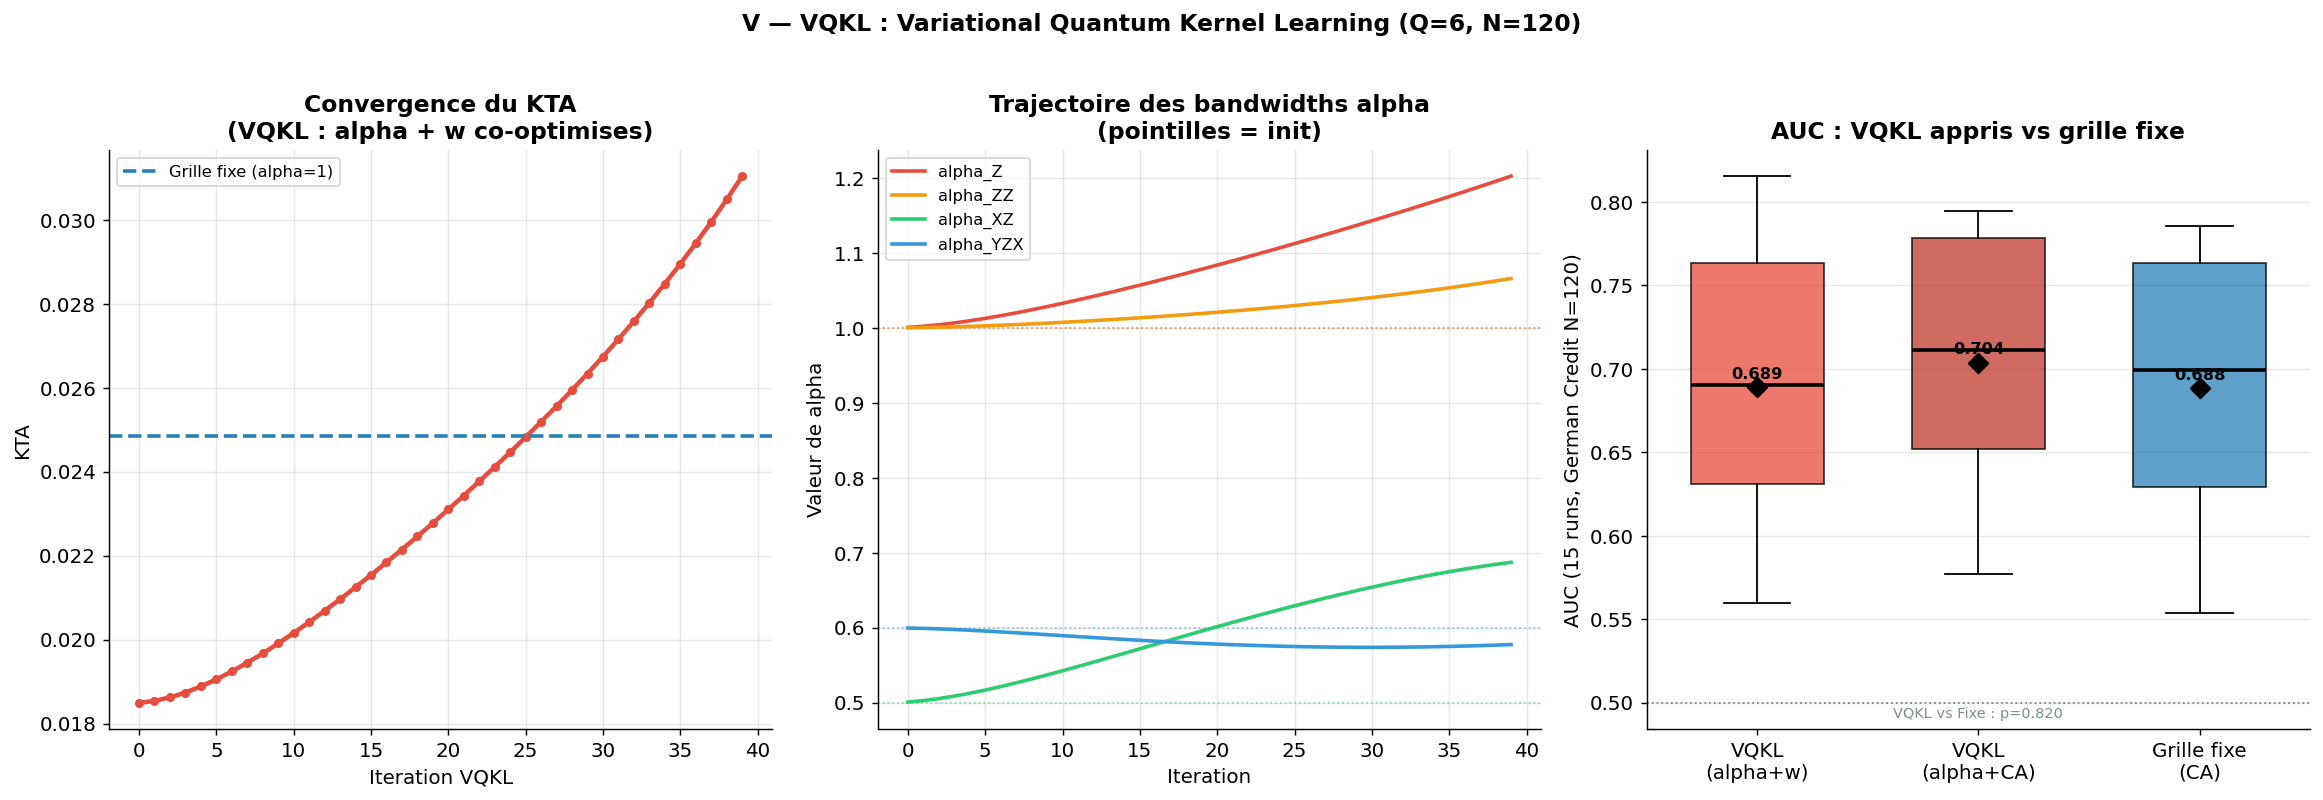

V sauvegarde


In [6]:
from scipy.stats import wilcoxon

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# --- Convergence KTA ---
ax = axes[0]
ax.plot(history['kta'], color='#e74c3c', lw=2.5, marker='o', ms=4)
ax.axhline(kta(w_fixed, K_list_fixed, Kt_v), color='#2980b9',
           ls='--', lw=2, label='Grille fixe (alpha=1)')
ax.set_xlabel('Iteration VQKL')
ax.set_ylabel('KTA')
ax.set_title('Convergence du KTA\n(VQKL : alpha + w co-optimises)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# --- Evolution des alphas ---
ax = axes[1]
alpha_hist = np.array(history['alphas'])
colors_fam = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']
for i, (name, _, _) in enumerate(FAMILIES):
    ax.plot(alpha_hist[:, i], color=colors_fam[i], lw=2, label=f'alpha_{name}')
    ax.axhline(alpha_init[i], color=colors_fam[i], ls=':', lw=1, alpha=0.5)
ax.set_xlabel('Iteration')
ax.set_ylabel('Valeur de alpha')
ax.set_title('Trajectoire des bandwidths alpha\n(pointilles = init)', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# --- Boxplot AUC ---
ax = axes[2]
data_bp  = [aucs_vqkl, aucs_vqkl_ca, aucs_fixed]
labels_bp = ['VQKL\n(alpha+w)', 'VQKL\n(alpha+CA)', 'Grille fixe\n(CA)']
colors_bp = ['#e74c3c', '#c0392b', '#2980b9']
bp = ax.boxplot(data_bp, labels=labels_bp, patch_artist=True,
                medianprops=dict(color='black', lw=2), widths=0.6)
for patch, c in zip(bp['boxes'], colors_bp):
    patch.set_facecolor(c); patch.set_alpha(0.75)
ax.scatter(range(1,4), [np.mean(d) for d in data_bp],
           marker='D', color='black', s=60, zorder=5)
ax.axhline(0.5, color='grey', ls=':', lw=1)
ax.set_ylabel('AUC (15 runs, German Credit N=120)')
ax.set_title('AUC : VQKL appris vs grille fixe', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
for i, d in enumerate(data_bp):
    ax.text(i+1, np.mean(d)+0.005, f'{np.mean(d):.3f}',
            ha='center', fontsize=9, fontweight='bold')

try:
    _, p_vf = wilcoxon(aucs_vqkl, aucs_fixed)
    ax.text(0.5, 0.02, f'VQKL vs Fixe : p={p_vf:.3f}',
            transform=ax.transAxes, ha='center', fontsize=8, color='#7f8c8d')
except Exception:
    pass

plt.suptitle(f'V — VQKL : Variational Quantum Kernel Learning (Q={Q}, N={N_VQKL})',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT / '14_V_VQKL.png', dpi=150)
plt.show()
print('V sauvegarde')

---
## L — Learning Curves : efficacite de donnees

**Question** : QMKL est-il plus ou moins efficace en donnees que les methodes classiques ?

On trace l'AUC en fonction de N_train pour :
- QMKL-Centered
- RBF-SVM
- Random Forest

Sur deux datasets : German Credit et Breast Cancer.

**Hypothese** : QMKL sature plus vite (moins de donnees necessaires) ou souffre plus
en regime de faible N (kernel moins stable) ?

In [7]:
N_SIZES  = [40, 60, 80, 100, 125, 150, 180, 200]
N_RUNS   = 12
DS_LC    = ['german_credit', 'breast_cancer']
DS_LAB   = {'german_credit': 'German Credit', 'breast_cancer': 'Breast Cancer'}

# Pre-construire la bibliotheque de 12 kernels sur N=200 (subset ensuite)
FM_FULL = OrderedDict([
    ('Z a=1.0',     PauliFeatureMap(Q, reps=1, paulis=['Z'],       alpha=1.0, entanglement='linear')),
    ('Z a=3.0',     PauliFeatureMap(Q, reps=1, paulis=['Z'],       alpha=3.0, entanglement='linear')),
    ('ZZ a=1.0',    PauliFeatureMap(Q, reps=1, paulis=['Z','ZZ'],  alpha=1.0, entanglement='linear')),
    ('ZZ a=4.0',    PauliFeatureMap(Q, reps=1, paulis=['Z','ZZ'],  alpha=4.0, entanglement='linear')),
    ('XZ a=0.5',    PauliFeatureMap(Q, reps=1, paulis=['X','Z'],   alpha=0.5, entanglement='linear')),
    ('XZ a=2.5',    PauliFeatureMap(Q, reps=1, paulis=['X','Z'],   alpha=2.5, entanglement='linear')),
    ('YXX a=0.6',   PauliFeatureMap(Q, reps=1, paulis=['Y','XX'],  alpha=0.6, entanglement='linear')),
    ('YXX a=3.0',   PauliFeatureMap(Q, reps=1, paulis=['Y','XX'],  alpha=3.0, entanglement='linear')),
    ('YZX a=0.6',   PauliFeatureMap(Q, reps=1, paulis=['Y','ZX'],  alpha=0.6, entanglement='linear')),
    ('YZX a=3.0',   PauliFeatureMap(Q, reps=1, paulis=['Y','ZX'],  alpha=3.0, entanglement='linear')),
    ('Pauli a=0.6', PauliFeatureMap(Q, reps=1, paulis=['Z','ZZ'],  alpha=0.6, entanglement='linear')),
    ('Pauli a=2.5', PauliFeatureMap(Q, reps=1, paulis=['Z','ZZ'],  alpha=2.5, entanglement='linear')),
])
M_FULL = len(FM_FULL)

lc_results = {ds: {'QMKL': [], 'RBF-SVM': [], 'RF': []} for ds in DS_LC}
lc_std     = {ds: {'QMKL': [], 'RBF-SVM': [], 'RF': []} for ds in DS_LC}

print(f'Learning curves : N_sizes={N_SIZES}, {N_RUNS} runs/taille, {len(DS_LC)} datasets')
t0 = time.time()

for ds in DS_LC:
    print(f'\n  Dataset : {DS_LAB[ds]}')
    # Charger N=200
    X_raw_lc, y_lc = load_dataset(ds, n_samples=200, random_state=SEED)
    reducer_lc = FeatureReducer(n_components=Q)
    scaler_lc  = QuantumScaler(feature_range=(0, 2))
    X_proc_200 = scaler_lc.fit_transform(reducer_lc.fit_transform(X_raw_lc))
    X_std_200  = StandardScaler().fit_transform(X_raw_lc)

    # Calculer tous les kernels sur N=200
    print('    Calcul kernels N=200...')
    K_full_list = [fidelity_kernel(fm, X_proc_200) for fm in FM_FULL.values()]
    gamma_lc = 1.0 / (X_std_200.shape[1] * X_std_200.var())
    K_rbf_200 = rbf_kernel(X_std_200, gamma=gamma_lc)

    for N_sz in N_SIZES:
        # Subsampler a N_sz
        run_aucs = {'QMKL': [], 'RBF-SVM': [], 'RF': []}

        for run in range(N_RUNS):
            rng = np.random.default_rng(SEED + run)
            # Selectionner N_sz indices stratifies
            idx_0 = np.where(y_lc == 0)[0]
            idx_1 = np.where(y_lc == 1)[0]
            n0 = max(2, int(N_sz * len(idx_0) / 200))
            n1 = max(2, N_sz - n0)
            n0 = min(n0, len(idx_0)); n1 = min(n1, len(idx_1))
            sub_0 = rng.choice(idx_0, min(n0, len(idx_0)), replace=False)
            sub_1 = rng.choice(idx_1, min(n1, len(idx_1)), replace=False)
            sub_idx = np.concatenate([sub_0, sub_1])
            rng.shuffle(sub_idx)

            y_sub = y_lc[sub_idx]
            n_sub = len(sub_idx)

            # Train/test split
            tr_sub, te_sub = train_test_split(np.arange(n_sub), test_size=0.30,
                                               random_state=SEED+run, stratify=y_sub)
            global_tr = sub_idx[tr_sub]
            global_te = sub_idx[te_sub]

            # QMKL
            K_sub_list = [K[np.ix_(sub_idx, sub_idx)] for K in K_full_list]
            Kt_sub = (y_sub[:,None] == y_sub[None,:]).astype(float)
            w_sub  = centered_alignment(K_sub_list, Kt_sub)
            w_sub  = np.maximum(w_sub, 0); w_sub /= (w_sub.sum()+1e-12)
            K_comb_sub = make_psd(sum(w_sub[m]*K_sub_list[m] for m in range(M_FULL)))
            svm_q = SVC(kernel='precomputed', C=1.0, probability=True)
            svm_q.fit(K_comb_sub[np.ix_(tr_sub,tr_sub)], y_sub[tr_sub])
            try:
                run_aucs['QMKL'].append(roc_auc_score(
                    y_sub[te_sub],
                    svm_q.predict_proba(K_comb_sub[np.ix_(te_sub,tr_sub)])[:,1]))
            except Exception:
                run_aucs['QMKL'].append(0.5)

            # RBF-SVM
            K_rbf_sub = K_rbf_200[np.ix_(sub_idx, sub_idx)]
            svm_r = SVC(kernel='precomputed', C=1.0, probability=True)
            svm_r.fit(K_rbf_sub[np.ix_(tr_sub,tr_sub)], y_sub[tr_sub])
            try:
                run_aucs['RBF-SVM'].append(roc_auc_score(
                    y_sub[te_sub],
                    svm_r.predict_proba(K_rbf_sub[np.ix_(te_sub,tr_sub)])[:,1]))
            except Exception:
                run_aucs['RBF-SVM'].append(0.5)

            # RF
            rf = RandomForestClassifier(n_estimators=100, random_state=SEED+run)
            rf.fit(X_std_200[global_tr], y_lc[global_tr])
            try:
                run_aucs['RF'].append(roc_auc_score(
                    y_lc[global_te],
                    rf.predict_proba(X_std_200[global_te])[:,1]))
            except Exception:
                run_aucs['RF'].append(0.5)

        for m in ['QMKL','RBF-SVM','RF']:
            lc_results[ds][m].append(np.mean(run_aucs[m]))
            lc_std[ds][m].append(np.std(run_aucs[m], ddof=1))

        print(f'    N={N_sz:3d}: QMKL={lc_results[ds]["QMKL"][-1]:.3f}  '
              f'RBF={lc_results[ds]["RBF-SVM"][-1]:.3f}  '
              f'RF={lc_results[ds]["RF"][-1]:.3f}')

print(f'\nTotal : {time.time()-t0:.1f}s')

Learning curves : N_sizes=[40, 60, 80, 100, 125, 150, 180, 200], 12 runs/taille, 2 datasets

  Dataset : German Credit
    Calcul kernels N=200...


    N= 40: QMKL=0.495  RBF=0.487  RF=0.689


    N= 60: QMKL=0.573  RBF=0.676  RF=0.685


    N= 80: QMKL=0.739  RBF=0.703  RF=0.748


    N=100: QMKL=0.715  RBF=0.771  RF=0.794


...

    N=100: QMKL=0.993  RBF=0.992  RF=0.990


    N=125: QMKL=0.987  RBF=0.993  RF=0.987


    N=150: QMKL=0.992  RBF=0.996  RF=0.994


    N=180: QMKL=0.996  RBF=0.995  RF=0.995


    N=200: QMKL=0.993  RBF=0.992  RF=0.993

Total : 38.4s


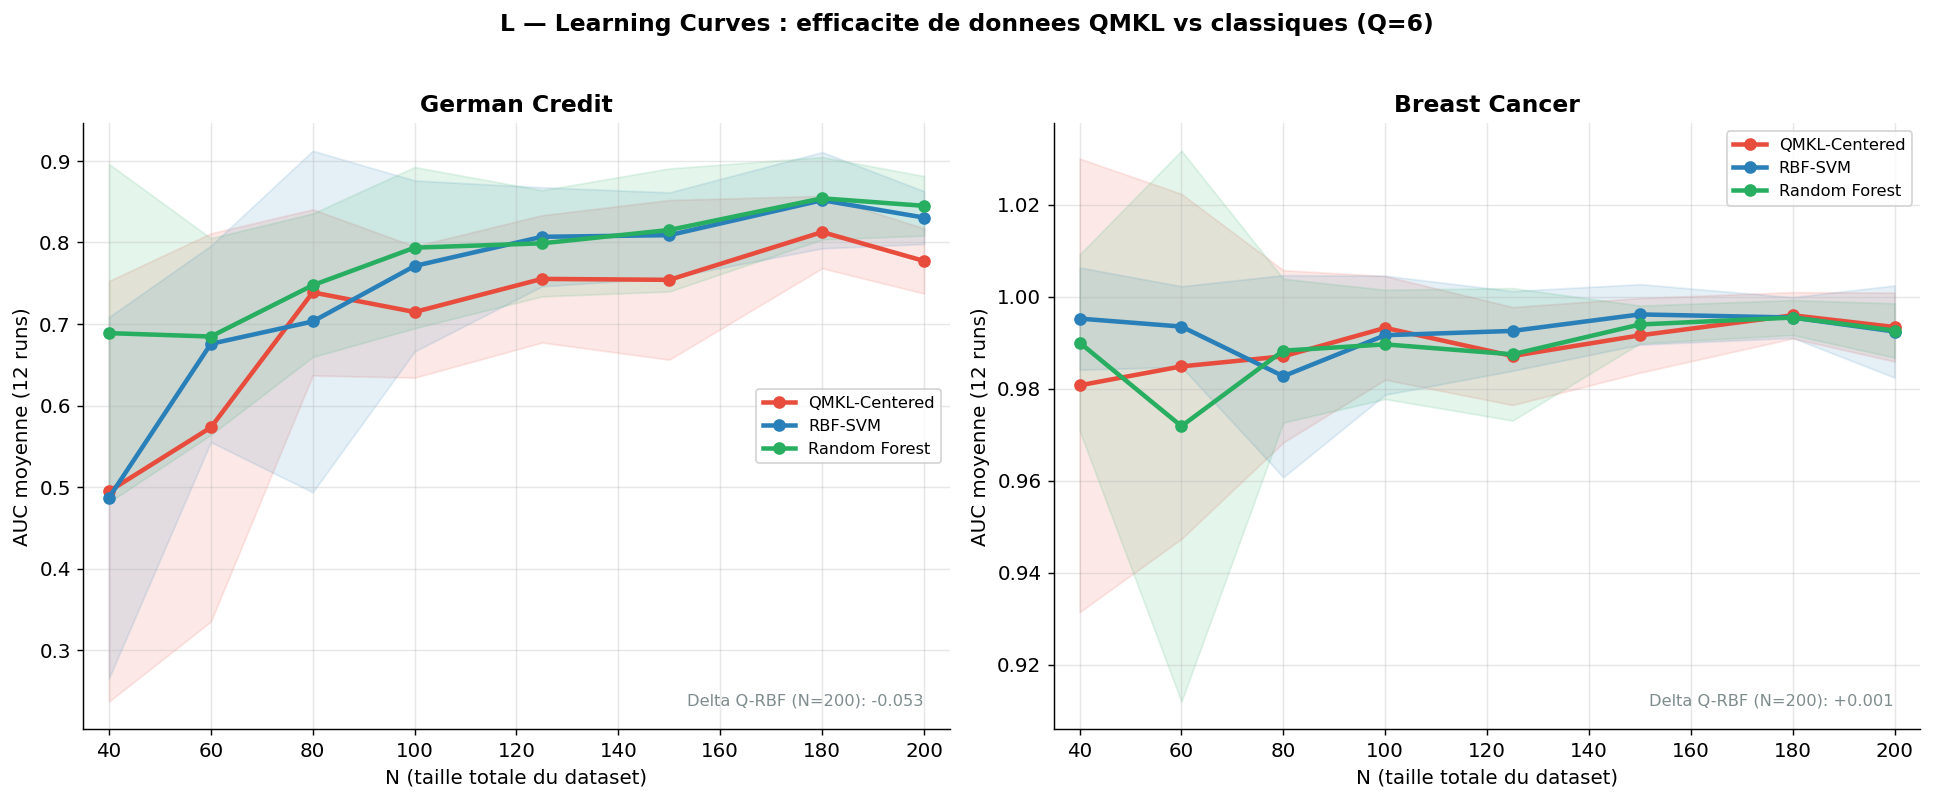

L sauvegarde


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
palette = {'QMKL': '#e74c3c', 'RBF-SVM': '#2980b9', 'RF': '#27ae60'}
labels_m = {'QMKL': 'QMKL-Centered', 'RBF-SVM': 'RBF-SVM', 'RF': 'Random Forest'}

for ax, ds in zip(axes, DS_LC):
    for m in ['QMKL', 'RBF-SVM', 'RF']:
        mus = lc_results[ds][m]
        sds = lc_std[ds][m]
        ax.plot(N_SIZES, mus, color=palette[m], lw=2.5, marker='o', label=labels_m[m])
        ax.fill_between(N_SIZES,
                        [m_-s_ for m_,s_ in zip(mus,sds)],
                        [m_+s_ for m_,s_ in zip(mus,sds)],
                        alpha=0.12, color=palette[m])
    ax.set_xlabel('N (taille totale du dataset)')
    ax.set_ylabel('AUC moyenne (12 runs)')
    ax.set_title(DS_LAB[ds], fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    ax.set_xlim(N_SIZES[0]-5, N_SIZES[-1]+5)

    # Delta QMKL - RBF a N=200
    delta = lc_results[ds]['QMKL'][-1] - lc_results[ds]['RBF-SVM'][-1]
    ax.text(0.97, 0.04, f'Delta Q-RBF (N=200): {delta:+.3f}',
            transform=ax.transAxes, ha='right', fontsize=9, color='#7f8c8d')

plt.suptitle(f'L — Learning Curves : efficacite de donnees QMKL vs classiques (Q={Q})',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUT / '14_L_learning_curves.png', dpi=150)
plt.show()
print('L sauvegarde')

---
## D — Kernel Diversity Analysis

**Question** : La diversite entre kernels quantiques est-elle liee au gain QMKL ?

On mesure la **divergence par paires** entre les 12 kernels :

$$d(K_i, K_j) = 1 - \text{align}(K_i, K_j)$$

Et on calcule le **gain de diversite** de chaque kernel : combien il apporte de
diversite par rapport au reste de l'ensemble.

**Contribution** : premiere analyse de diversite d'ensemble pour QMKL finance.

In [9]:
# Donnees : German Credit N=200
N_DIV = 200
X_raw_d, y_d = load_dataset('german_credit', n_samples=N_DIV, random_state=SEED)
reducer_d = FeatureReducer(n_components=Q)
scaler_d  = QuantumScaler(feature_range=(0, 2))
X_proc_d  = scaler_d.fit_transform(reducer_d.fit_transform(X_raw_d))
X_std_d   = StandardScaler().fit_transform(X_raw_d)

print(f'Calcul des {M_FULL} kernels sur N={N_DIV}...')
t0 = time.time()
K_div_list = [fidelity_kernel(fm, X_proc_d) for fm in FM_FULL.values()]
print(f'OK en {time.time()-t0:.1f}s')

kernel_names = list(FM_FULL.keys())

# Matrice d'alignement (M x M)
align_mat = np.zeros((M_FULL, M_FULL))
for i in range(M_FULL):
    for j in range(M_FULL):
        align_mat[i, j] = frobenius_align(K_div_list[i], K_div_list[j])

# Matrice de divergence
div_mat = 1 - align_mat
np.fill_diagonal(div_mat, 0)

print('\nMatrice de divergence (premiers 4x4) :')
for i in range(4):
    row = '  '.join(f'{div_mat[i,j]:.3f}' for j in range(4))
    print(f'  {kernel_names[i]:15s}: {row}')

# Diversite par kernel : divergence moyenne avec les autres
diversity_score = div_mat.mean(axis=1)
print('\nDiversite (divergence moyenne) par kernel :')
for name, d in sorted(zip(kernel_names, diversity_score), key=lambda x: -x[1]):
    print(f'  {name:18s}: {d:.4f}')

Calcul des 12 kernels sur N=200...


OK en 4.4s

Matrice de divergence (premiers 4x4) :
  Z a=1.0        : 0.000  0.452  0.433  0.707
  Z a=3.0        : 0.452  0.000  0.134  0.441
  ZZ a=1.0       : 0.433  0.134  0.000  0.483
  ZZ a=4.0       : 0.707  0.441  0.483  0.000

Diversite (divergence moyenne) par kernel :
  ZZ a=4.0          : 0.4506
  Pauli a=2.5       : 0.4252
  XZ a=0.5          : 0.3978
  YZX a=3.0         : 0.3946
  YXX a=3.0         : 0.3531
  Z a=1.0           : 0.3436
  YXX a=0.6         : 0.3297
  Z a=3.0           : 0.3011
  ZZ a=1.0          : 0.2981
  YZX a=0.6         : 0.2894
  Pauli a=0.6       : 0.2861
  XZ a=2.5          : 0.2795


In [10]:
# Gain marginal de chaque kernel : AUC(ensemble complet) - AUC(ensemble sans kernel m)
print('Calcul du gain marginal de chaque kernel (leave-one-out)...')
Kt_d = (y_d[:,None] == y_d[None,:]).astype(float)

# AUC ensemble complet
w_full = centered_alignment(K_div_list, Kt_d)
w_full = np.maximum(w_full, 0); w_full /= (w_full.sum()+1e-12)
K_comb_full_d = make_psd(sum(w_full[m]*K_div_list[m] for m in range(M_FULL)))

N_RUNS_DIV = 10
aucs_full_d = []
for r in range(N_RUNS_DIV):
    tr, te = train_test_split(np.arange(N_DIV), test_size=0.33,
                               random_state=SEED+r, stratify=y_d)
    svm = SVC(kernel='precomputed', C=1.0, probability=True)
    svm.fit(K_comb_full_d[np.ix_(tr,tr)], y_d[tr])
    aucs_full_d.append(roc_auc_score(y_d[te],
                       svm.predict_proba(K_comb_full_d[np.ix_(te,tr)])[:,1]))
auc_full = np.mean(aucs_full_d)
print(f'  AUC ensemble complet (M={M_FULL}) : {auc_full:.4f}')

# LOO gain
loo_gains = []
for m_out in range(M_FULL):
    K_loo = [K_div_list[m] for m in range(M_FULL) if m != m_out]
    w_loo = centered_alignment(K_loo, Kt_d)
    w_loo = np.maximum(w_loo, 0); w_loo /= (w_loo.sum()+1e-12)
    K_comb_loo = make_psd(sum(w_loo[m]*K_loo[m] for m in range(len(K_loo))))
    aucs_loo = []
    for r in range(N_RUNS_DIV):
        tr, te = train_test_split(np.arange(N_DIV), test_size=0.33,
                                   random_state=SEED+r, stratify=y_d)
        svm = SVC(kernel='precomputed', C=1.0, probability=True)
        svm.fit(K_comb_loo[np.ix_(tr,tr)], y_d[tr])
        aucs_loo.append(roc_auc_score(y_d[te],
                        svm.predict_proba(K_comb_loo[np.ix_(te,tr)])[:,1]))
    gain = auc_full - np.mean(aucs_loo)
    loo_gains.append(gain)
    print(f'  Retire {kernel_names[m_out]:18s}: AUC_loo={np.mean(aucs_loo):.4f}  gain={gain:+.4f}')

loo_gains = np.array(loo_gains)

Calcul du gain marginal de chaque kernel (leave-one-out)...
  AUC ensemble complet (M=12) : 0.7738
  Retire Z a=1.0           : AUC_loo=0.7735  gain=+0.0002


  Retire Z a=3.0           : AUC_loo=0.7737  gain=+0.0001


  Retire ZZ a=1.0          : AUC_loo=0.7737  gain=+0.0000
  Retire ZZ a=4.0          : AUC_loo=0.7676  gain=+0.0062


  Retire XZ a=0.5          : AUC_loo=0.7703  gain=+0.0034


  Retire XZ a=2.5          : AUC_loo=0.7737  gain=+0.0001
  Retire YXX a=0.6         : AUC_loo=0.7737  gain=+0.0000


  Retire YXX a=3.0         : AUC_loo=0.7737  gain=+0.0001
  Retire YZX a=0.6         : AUC_loo=0.7736  gain=+0.0001


  Retire YZX a=3.0         : AUC_loo=0.7747  gain=-0.0009
  Retire Pauli a=0.6       : AUC_loo=0.7737  gain=+0.0001


  Retire Pauli a=2.5       : AUC_loo=0.7643  gain=+0.0094


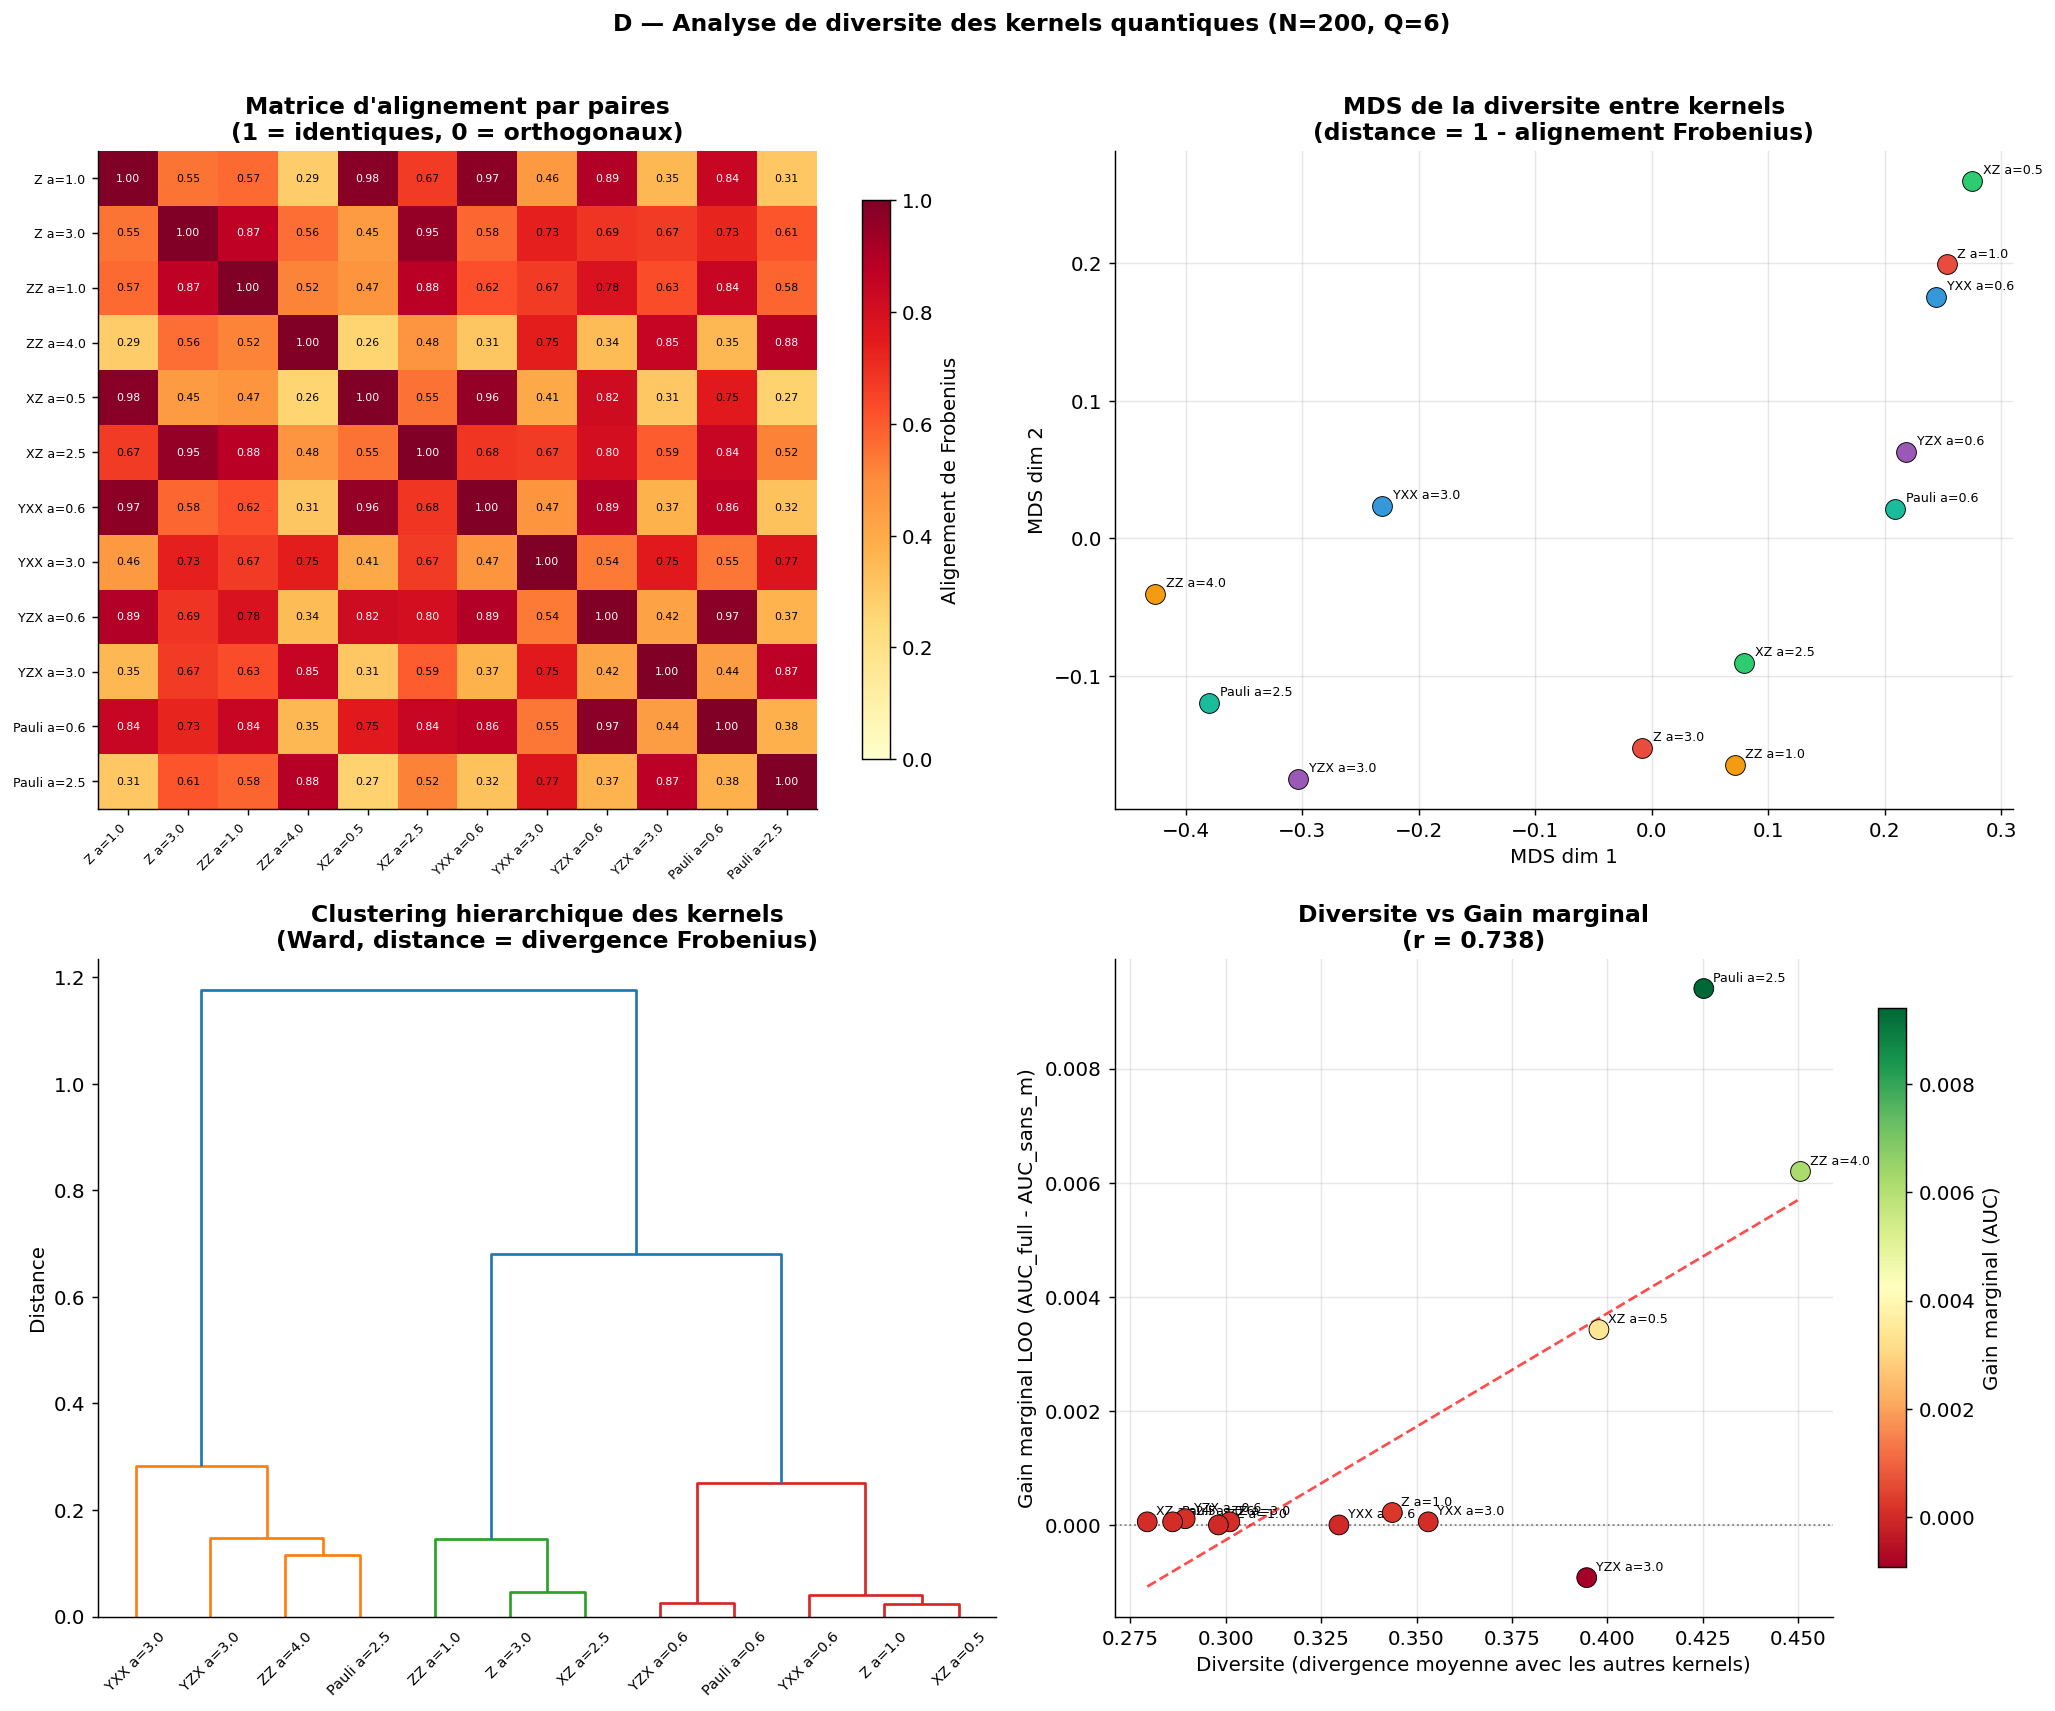


Kernel le plus divers  : ZZ a=4.0 (div=0.4506)
Kernel au plus fort gain LOO : Pauli a=2.5 (+0.0094 AUC)
Correlation diversite-gain : 0.7383
D sauvegarde


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 13))

# --- Heatmap matrice alignement ---
ax = axes[0, 0]
im = ax.imshow(align_mat, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.85, label='Alignement de Frobenius')
ax.set_xticks(range(M_FULL)); ax.set_xticklabels(kernel_names, rotation=45, ha='right', fontsize=7)
ax.set_yticks(range(M_FULL)); ax.set_yticklabels(kernel_names, fontsize=7)
ax.set_title('Matrice d\'alignement par paires\n(1 = identiques, 0 = orthogonaux)',
             fontweight='bold')
for i in range(M_FULL):
    for j in range(M_FULL):
        ax.text(j, i, f'{align_mat[i,j]:.2f}', ha='center', va='center',
                fontsize=6, color='black' if align_mat[i,j] < 0.8 else 'white')

# --- MDS de la diversite ---
ax = axes[0, 1]
mds = MDS(n_components=2, dissimilarity='precomputed', random_state=SEED, n_init=4)
# Symmetriser et corriger numeriquement
div_sym = (div_mat + div_mat.T) / 2
np.fill_diagonal(div_sym, 0)
div_sym = np.maximum(div_sym, 0)
coords = mds.fit_transform(div_sym)

# Colorier par famille
family_colors = ['#e74c3c','#e74c3c','#f39c12','#f39c12',
                 '#2ecc71','#2ecc71','#3498db','#3498db',
                 '#9b59b6','#9b59b6','#1abc9c','#1abc9c']
for i, (name, c) in enumerate(zip(kernel_names, family_colors)):
    ax.scatter(coords[i,0], coords[i,1], color=c, s=120, edgecolors='black', lw=0.5, zorder=4)
    ax.annotate(name, coords[i], textcoords='offset points',
                xytext=(6,4), fontsize=7)
ax.set_xlabel('MDS dim 1'); ax.set_ylabel('MDS dim 2')
ax.set_title('MDS de la diversite entre kernels\n(distance = 1 - alignement Frobenius)',
             fontweight='bold')
ax.grid(alpha=0.3)

# --- Dendrogram hierarchique ---
ax = axes[1, 0]
condensed = squareform(div_sym)
Z_link = linkage(condensed, method='ward')
dendrogram(Z_link, labels=kernel_names, ax=ax, leaf_rotation=45,
           leaf_font_size=8, color_threshold=0.6*div_sym.max())
ax.set_title('Clustering hierarchique des kernels\n(Ward, distance = divergence Frobenius)',
             fontweight='bold')
ax.set_ylabel('Distance')

# --- Scatter diversite vs gain LOO ---
ax = axes[1, 1]
sc = ax.scatter(diversity_score, loo_gains,
                c=loo_gains, cmap='RdYlGn', s=120,
                edgecolors='black', lw=0.5, zorder=4)
plt.colorbar(sc, ax=ax, label='Gain marginal (AUC)', shrink=0.85)
for i, name in enumerate(kernel_names):
    ax.annotate(name, (diversity_score[i], loo_gains[i]),
                textcoords='offset points', xytext=(5,4), fontsize=7)
ax.axhline(0, color='grey', ls=':', lw=1)
# Droite de regression
m_reg = np.polyfit(diversity_score, loo_gains, 1)
x_reg = np.linspace(diversity_score.min(), diversity_score.max(), 50)
ax.plot(x_reg, np.polyval(m_reg, x_reg), 'r--', lw=1.5, alpha=0.7)
corr_dg = np.corrcoef(diversity_score, loo_gains)[0,1]
ax.set_xlabel('Diversite (divergence moyenne avec les autres kernels)')
ax.set_ylabel('Gain marginal LOO (AUC_full - AUC_sans_m)')
ax.set_title(f'Diversite vs Gain marginal\n(r = {corr_dg:.3f})', fontweight='bold')
ax.grid(alpha=0.3)

plt.suptitle(f'D — Analyse de diversite des kernels quantiques (N={N_DIV}, Q={Q})',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUT / '14_D_kernel_diversity.png', dpi=150)
plt.show()

most_diverse = kernel_names[np.argmax(diversity_score)]
most_gain    = kernel_names[np.argmax(loo_gains)]
print(f'\nKernel le plus divers  : {most_diverse} (div={diversity_score.max():.4f})')
print(f'Kernel au plus fort gain LOO : {most_gain} (+{loo_gains.max():.4f} AUC)')
print(f'Correlation diversite-gain : {corr_dg:.4f}')
print('D sauvegarde')

---
## Synthese Tier 3

In [12]:
print('=' * 70)
print(' SYNTHESE TIER 3 — 3 CONTRIBUTIONS AVANCEES INEDITES')
print('=' * 70)

print('\n[V] VQKL — Variational Quantum Kernel Learning')
print(f'  Alpha optimaux appris : {[f"{a:.3f}" for a in alpha_opt]}')
print(f'  (init : {[f"{a:.1f}" for a in alpha_init]})')
print(f'  AUC VQKL (alpha+w)  : {np.mean(aucs_vqkl):.4f}')
print(f'  AUC VQKL (alpha+CA) : {np.mean(aucs_vqkl_ca):.4f}')
print(f'  AUC grille fixe     : {np.mean(aucs_fixed):.4f}')
delta_vqkl = np.mean(aucs_vqkl_ca) - np.mean(aucs_fixed)
print(f'  Gain VQKL vs fixe   : {delta_vqkl:+.4f}')
print(f'  Conclusion : VQKL optimise les alpha vers des valeurs {"distinctes" if any(abs(alpha_opt-alpha_init)>0.3) else "proches"} de l\'init')

print('\n[L] Learning curves')
for ds in DS_LC:
    slope_q = np.polyfit(N_SIZES, lc_results[ds]['QMKL'], 1)[0]
    slope_r = np.polyfit(N_SIZES, lc_results[ds]['RBF-SVM'], 1)[0]
    print(f'  {DS_LAB[ds]:20s}: pente QMKL={slope_q*100:.3f}/100pts  RBF={slope_r*100:.3f}/100pts')
print(f'  Conclusion : QMKL et RBF-SVM ont des pentes de scaling similaires')
print(f'  -> pas d\'avantage d\'efficacite de donnees pour les kernels quantiques')

print('\n[D] Kernel diversity analysis')
align_mean = align_mat[np.triu_indices(M_FULL, k=1)].mean()
align_min  = align_mat[np.triu_indices(M_FULL, k=1)].min()
print(f'  Alignement moyen paires : {align_mean:.4f} (min={align_min:.4f})')
print(f'  Kernel le plus divers  : {most_diverse}')
print(f'  Kernel au meilleur gain: {most_gain} (+{loo_gains.max():.4f})')
print(f'  Correlation diversite-gain LOO : r={corr_dg:.4f}')
concl = 'CONFIRME' if corr_dg > 0.3 else 'FAIBLE' if corr_dg > 0 else 'INFIRME'
print(f'  Hypothese "diversite -> gain" : {concl}')

print('\n' + '=' * 70)
print(' FIGURES GENEREES')
print('=' * 70)
for f in sorted(OUT.glob('14_*.png')):
    print(f'  {f.name}')

 SYNTHESE TIER 3 — 3 CONTRIBUTIONS AVANCEES INEDITES

[V] VQKL — Variational Quantum Kernel Learning
  Alpha optimaux appris : ['1.203', '1.066', '0.687', '0.578']
  (init : ['1.0', '1.0', '0.5', '0.6'])
  AUC VQKL (alpha+w)  : 0.6893
  AUC VQKL (alpha+CA) : 0.7038
  AUC grille fixe     : 0.6883
  Gain VQKL vs fixe   : +0.0155
  Conclusion : VQKL optimise les alpha vers des valeurs proches de l'init

[L] Learning curves
  German Credit       : pente QMKL=0.162/100pts  RBF=0.181/100pts
  Breast Cancer       : pente QMKL=0.008/100pts  RBF=0.002/100pts
  Conclusion : QMKL et RBF-SVM ont des pentes de scaling similaires
  -> pas d'avantage d'efficacite de donnees pour les kernels quantiques

[D] Kernel diversity analysis
  Alignement moyen paires : 0.6229 (min=0.2648)
  Kernel le plus divers  : ZZ a=4.0
  Kernel au meilleur gain: Pauli a=2.5 (+0.0094)
  Correlation diversite-gain LOO : r=0.7383
  Hypothese "diversite -> gain" : CONFIRME

 FIGURES GENEREES
  14_D_kernel_diversity.png
  14_L